# The Police Dataset

## Import Libraries

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/police.csv', engine='pyarrow')

## EDA

In [3]:
df.tail(5)

,stop_date,stop_time,country_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
65530,12-06-2012,17:54:00,NaN,F,1987.0,25.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
65531,12-06-2012,22:22:00,NaN,M,1954.0,58.0,White,Speeding,Speeding,False,None,Warning,False,0-15 Min,False
65532,12-06-2012,23:20:00,NaN,M,1985.0,27.0,Black,Equipment/Inspection Violation,Equipment,False,None,Citation,False,0-15 Min,False
65533,12-07-2012,00:23:00,NaN,None,NaN,NaN,None,None,None,False,None,None,None,None,False
65534,12-07-2012,00:30:00,NaN,F,1985.0,27.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False


In [4]:
df.head(5)

,stop_date,stop_time,country_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55:00,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
1,1/18/2005,08:15:00,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
2,1/23/2005,23:15:00,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
3,2/20/2005,17:15:00,NaN,M,1986.0,19.0,White,Call for Service,Other,False,None,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False


In [5]:
df.shape

(65535, 15)

In [6]:
df.size

983025

In [7]:
df.dtypes

stop_date              object
stop_time              object
country_name          float64
driver_gender          object
driver_age_raw        float64
driver_age            float64
driver_race            object
violation_raw          object
violation              object
search_conducted         bool
search_type            object
stop_outcome           object
is_arrested            object
stop_duration          object
drugs_related_stop       bool
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stop_date           65535 non-null  object 
 1   stop_time           65535 non-null  object 
 2   country_name        0 non-null      float64
 3   driver_gender       61474 non-null  object 
 4   driver_age_raw      61481 non-null  float64
 5   driver_age          61228 non-null  float64
 6   driver_race         61475 non-null  object 
 7   violation_raw       61475 non-null  object 
 8   violation           61475 non-null  object 
 9   search_conducted    65535 non-null  bool   
 10  search_type         2479 non-null   object 
 11  stop_outcome        61475 non-null  object 
 12  is_arrested         61475 non-null  object 
 13  stop_duration       61475 non-null  object 
 14  drugs_related_stop  65535 non-null  bool   
dtypes: bool(2), float64(3), object(10)
memory usage: 6.6+

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
country_name,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
driver_age_raw,61481.0,1967.791106,121.050106,0.0,1965.0,1978.0,1985.0,8801.0
driver_age,61228.0,34.148984,12.760710,15.0,23.0,31.0,43.0,88.0


## Data Cleaning

### (Data Cleaning) Remove the column that only contains missing values. 

In [10]:
df.isnull().sum()

stop_date                 0
stop_time                 0
country_name          65535
driver_gender          4061
driver_age_raw         4054
driver_age             4307
driver_race            4060
violation_raw          4060
violation              4060
search_conducted          0
search_type           63056
stop_outcome           4060
is_arrested            4060
stop_duration          4060
drugs_related_stop        0
dtype: int64

In [11]:
df.drop(columns='country_name', inplace=True)

In [12]:
df.head()

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55:00,M,1985.0,20.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
1,1/18/2005,08:15:00,M,1965.0,40.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
2,1/23/2005,23:15:00,M,1972.0,33.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
3,2/20/2005,17:15:00,M,1986.0,19.0,White,Call for Service,Other,False,None,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00:00,F,1984.0,21.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False


### (Based on Filtering + Value Counts) For Speeding , were Men or Women stopped more often? 

In [13]:
df[df.violation == 'Speeding'].driver_gender.value_counts()

driver_gender
M    25517
F    11686
Name: count, dtype: int64

<Axes: ylabel='count'>

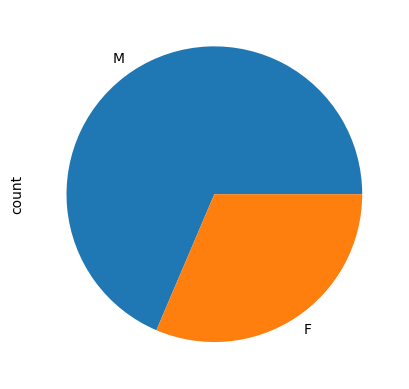

In [14]:
df[df.violation == 'Speeding'].driver_gender.value_counts().plot(kind='pie')

### (Groupby) Does gender affect who gets searched during a stop? 

In [15]:
# Total Conducted
total_conducted = df.search_conducted.sum()
print(total_conducted)

2479


In [16]:
df.groupby('driver_gender').search_conducted.value_counts()

driver_gender  search_conducted
F              False               15944
               True                  366
M              False               43051
               True                 2113
Name: count, dtype: int64

<Axes: ylabel='driver_gender,search_conducted'>

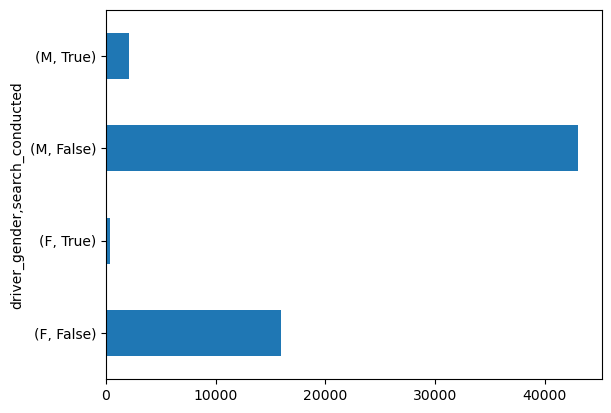

In [17]:
df.groupby('driver_gender').search_conducted.value_counts().plot(kind='barh')

In [18]:
df.groupby('driver_gender').search_conducted.sum()

driver_gender
F     366
M    2113
Name: search_conducted, dtype: int64

<Axes: ylabel='driver_gender'>

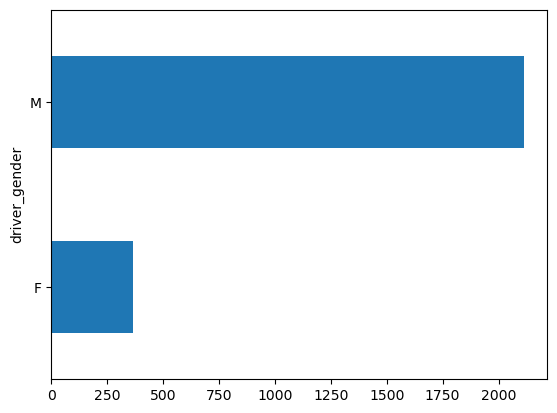

In [19]:
df.groupby('driver_gender').search_conducted.sum().plot(kind='barh')

### (mapping + data-type casting) What is the mean stop_duration?

In [20]:
df.head()

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55:00,M,1985.0,20.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
1,1/18/2005,08:15:00,M,1965.0,40.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
2,1/23/2005,23:15:00,M,1972.0,33.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False
3,2/20/2005,17:15:00,M,1986.0,19.0,White,Call for Service,Other,False,None,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00:00,F,1984.0,21.0,White,Speeding,Speeding,False,None,Citation,False,0-15 Min,False


In [21]:
df['stop_duration'].value_counts()

stop_duration
0-15 Min     47379
16-30 Min    11448
30+ Min       2647
2                1
Name: count, dtype: int64

In [22]:
df['stop_duration'] = df['stop_duration'].map({'0-15 Min': 7.5, '16-30 Min': 24, '30+ Min': 45})

In [25]:
print(df.stop_duration.mean())

12.187420698181345


### (Groupby , Describe) - Compare the age distributions for each violation.

In [27]:
df.groupby('violation').driver_age.describe()

,count,mean,std,min,25%,50%,75%,max
violation,,,,,,,,
Equipment,6507.0,31.682957,11.380671,16.0,23.0,28.0,39.0,81.0
Moving violation,11876.0,36.736443,13.258350,15.0,25.0,35.0,47.0,86.0
Other,3477.0,40.362381,12.754423,16.0,30.0,41.0,50.0,86.0
Registration/plates,2240.0,32.656696,11.150780,16.0,24.0,30.0,40.0,74.0
Seat belt,3.0,30.333333,10.214369,23.0,24.5,26.0,34.0,42.0
Speeding,37120.0,33.262581,12.615781,15.0,23.0,30.0,42.0,88.0
